# Imports

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd
from scipy.stats import skew, ttest_ind
from functions import plot
from statsmodels.stats.multitest import multipletests

# Variables

In [3]:
log_trans = True

# Format data

In [4]:
df_org = pd.read_excel("../data/unformated/Daten_Label_24hWt.xlsx", sheet_name="formatted")
rows_unl = [i for i in range(len(df_org)) if i % 2 == 0]
rows_l = [i for i in range(len(df_org)) if i % 2 != 0]
df = df_org.drop(rows_l, axis=0)
df_l = df_org.drop(rows_unl, axis=0)

In [5]:
# add labeled values as new columns
cols = df_org.columns[1:]
for col in cols:
    df[f"{col}_l"] = df_l[col].values

df

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,exp2_37deg_3_l,exp2_37deg_4_l,exp4_22deg_1_l,exp4_22deg_2_l,exp4_22deg_3_l,exp4_22deg_4_l,exp4_37deg_1_l,exp4_37deg_2_l,exp4_37deg_3_l,exp4_37deg_4_l
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,1.297905,1.413610,2.152663,2.088974,1.241209,1.523959,10.029840,15.876957,14.942153,10.288102
2,Cer_d18:1_16:0,0.000000,0.000000,0.000000,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,4.607286,4.431282,3.054066,3.394669,2.110951,2.512315,31.621042,33.167724,26.167475,24.345149
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,0.312451,0.359753,4.698023,4.268724,2.673547,3.430581,7.514651,9.460271,11.039339,6.770959
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,0.556659,0.517282,4.570194,4.422733,3.048503,2.931791,9.367357,9.167949,8.102832,7.341369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC(t18:0/h26:1),0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
172,GIPC(t18:1/h26:0),5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,0.000000,0.000000,1.440343,1.202063,0.000000,0.042314,0.000000,0.685638,1.190872,0.000000
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,0.003247,0.000000,0.000000,0.000000,0.000000,0.020399,0.023651,0.000000,0.000000,0.000000
176,GIPC_t18:0_h28:1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


# Preprocessing
## Replace zero values
- replace zero values with half minimum value, because log(0) not possible

In [6]:
half_min = np.min([val for val in df.filter(regex=r"^(?!.*compound).*$").values.flatten() if val != 0]) / 2
print("Half minimum:", half_min)

for col in df.columns:
    if col == "compound":
        continue

    df[col] = df[col].replace(0, half_min)

df

Half minimum: 4.0672700112186134e-05


,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,exp2_37deg_3_l,exp2_37deg_4_l,exp4_22deg_1_l,exp4_22deg_2_l,exp4_22deg_3_l,exp4_22deg_4_l,exp4_37deg_1_l,exp4_37deg_2_l,exp4_37deg_3_l,exp4_37deg_4_l
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,1.297905,1.413610,2.152663,2.088974,1.241209,1.523959,10.029840,15.876957,14.942153,10.288102
2,Cer_d18:1_16:0,0.000041,0.000041,0.000041,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,4.607286,4.431282,3.054066,3.394669,2.110951,2.512315,31.621042,33.167724,26.167475,24.345149
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,0.312451,0.359753,4.698023,4.268724,2.673547,3.430581,7.514651,9.460271,11.039339,6.770959
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,0.556659,0.517282,4.570194,4.422733,3.048503,2.931791,9.367357,9.167949,8.102832,7.341369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC(t18:0/h26:1),0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,...,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041
172,GIPC(t18:1/h26:0),5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,0.000041,0.000041,1.440343,1.202063,0.000041,0.042314,0.000041,0.685638,1.190872,0.000041
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,0.003247,0.000041,0.000041,0.000041,0.000041,0.020399,0.023651,0.000041,0.000041,0.000041
176,GIPC_t18:0_h28:1,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,...,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041


## Relative values

In [7]:
cols = df.columns[1:]

for col in cols:
    exp = col.split("_")[0]
    exp_cols = [col for col in cols if "rel" not in col and exp in col]
    sum_exp = df[exp_cols].to_numpy().sum()
    abs_values = df[col].values
    rel_values = [val/sum_exp for val in abs_values]

    df[f"{col}_rel"] = rel_values

    # print("Experiment:", exp)
    # print("Experiment columns:", exp_cols)
    # print("Sum experiment:", sum_exp)
    # print("Column:", col)
    # print("Absolute values:", abs_values)
    # print("Relative values:", rel_values)
df

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,exp2_37deg_3_l_rel,exp2_37deg_4_l_rel,exp4_22deg_1_l_rel,exp4_22deg_2_l_rel,exp4_22deg_3_l_rel,exp4_22deg_4_l_rel,exp4_37deg_1_l_rel,exp4_37deg_2_l_rel,exp4_37deg_3_l_rel,exp4_37deg_4_l_rel
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,1.162409e-03,1.266035e-03,2.456538e-04,2.383859e-04,1.416420e-04,1.739084e-04,1.144567e-03,1.811818e-03,1.705142e-03,1.174039e-03
2,Cer_d18:1_16:0,0.000041,0.000041,0.000041,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,3.642664e-08,3.642664e-08,4.641415e-09,4.641415e-09,4.641415e-09,4.641415e-09,4.641415e-09,4.641415e-09,4.641415e-09,4.641415e-09
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,4.126304e-03,3.968674e-03,3.485184e-04,3.873868e-04,2.408937e-04,2.866959e-04,3.608474e-03,3.784976e-03,2.986134e-03,2.778177e-03
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,2.798325e-04,3.221959e-04,5.361206e-04,4.871307e-04,3.050952e-04,3.914849e-04,8.575436e-04,1.079570e-03,1.259768e-03,7.726764e-04
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,4.985460e-04,4.632801e-04,5.215333e-04,5.047056e-04,3.478836e-04,3.345650e-04,1.068967e-03,1.046212e-03,9.246646e-04,8.377694e-04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC(t18:0/h26:1),0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,...,3.642664e-08,3.642664e-08,4.641415e-09,4.641415e-09,4.641415e-09,4.641415e-09,4.641415e-09,4.641415e-09,4.641415e-09,4.641415e-09
172,GIPC(t18:1/h26:0),5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,3.642664e-08,3.642664e-08,1.643665e-04,1.371749e-04,4.641415e-09,4.828770e-06,4.641415e-09,7.824247e-05,1.358979e-04,4.641415e-09
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,2.908229e-06,3.642664e-08,4.641415e-09,4.641415e-09,4.641415e-09,2.327842e-06,2.698922e-06,4.641415e-09,4.641415e-09,4.641415e-09
176,GIPC_t18:0_h28:1,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,...,3.642664e-08,3.642664e-08,4.641415e-09,4.641415e-09,4.641415e-09,4.641415e-09,4.641415e-09,4.641415e-09,4.641415e-09,4.641415e-09


In [8]:
df.filter(regex="exp2").filter(regex="rel").to_numpy().sum()

np.float64(0.9999999999999999)

In [9]:
df.filter(regex="exp4").filter(regex="rel").to_numpy().sum()

np.float64(1.0)

## log Transformation

In [10]:
if log_trans == True:
    rel_cols = [c for c in df.columns if "rel" in c]
    print(rel_cols)

    for col in rel_cols:
        df[col] = np.log(df[col].values)

df

['exp2_22deg_1_rel', 'exp2_22deg_2_rel', 'exp2_22deg_3_rel', 'exp2_22deg_4_rel', 'exp2_37deg_1_rel', 'exp2_37deg_2_rel', 'exp2_37deg_3_rel', 'exp2_37deg_4_rel', 'exp4_22deg_1_rel', 'exp4_22deg_2_rel', 'exp4_22deg_3_rel', 'exp4_22deg_4_rel', 'exp4_37deg_1_rel', 'exp4_37deg_2_rel', 'exp4_37deg_3_rel', 'exp4_37deg_4_rel', 'exp2_22deg_1_l_rel', 'exp2_22deg_2_l_rel', 'exp2_22deg_3_l_rel', 'exp2_22deg_4_l_rel', 'exp2_37deg_1_l_rel', 'exp2_37deg_2_l_rel', 'exp2_37deg_3_l_rel', 'exp2_37deg_4_l_rel', 'exp4_22deg_1_l_rel', 'exp4_22deg_2_l_rel', 'exp4_22deg_3_l_rel', 'exp4_22deg_4_l_rel', 'exp4_37deg_1_l_rel', 'exp4_37deg_2_l_rel', 'exp4_37deg_3_l_rel', 'exp4_37deg_4_l_rel']


,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,exp2_37deg_3_l_rel,exp2_37deg_4_l_rel,exp4_22deg_1_l_rel,exp4_22deg_2_l_rel,exp4_22deg_3_l_rel,exp4_22deg_4_l_rel,exp4_37deg_1_l_rel,exp4_37deg_2_l_rel,exp4_37deg_3_l_rel,exp4_37deg_4_l_rel
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,-6.757261,-6.671866,-8.311587,-8.341620,-8.862208,-8.656982,-6.772728,-6.313424,-6.374107,-6.747305
2,Cer_d18:1_16:0,0.000041,0.000041,0.000041,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,-17.127966,-17.127966,-19.188247,-19.188247,-19.188247,-19.188247,-19.188247,-19.188247,-19.188247,-19.188247
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,-5.490373,-5.529323,-7.961819,-7.856087,-8.331155,-8.157089,-5.624470,-5.576716,-5.813776,-5.885960
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,-8.181319,-8.040351,-7.531151,-7.626978,-8.094887,-7.845564,-7.061439,-6.831192,-6.676828,-7.165650
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,-7.603815,-7.677179,-7.558738,-7.591535,-7.963643,-8.002680,-6.841062,-6.862579,-6.986079,-7.084768
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC(t18:0/h26:1),0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,...,-17.127966,-17.127966,-19.188247,-19.188247,-19.188247,-19.188247,-19.188247,-19.188247,-19.188247,-19.188247
172,GIPC(t18:1/h26:0),5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,-17.127966,-17.127966,-8.713412,-8.894254,-19.188247,-12.240919,-19.188247,-9.455698,-8.903607,-19.188247
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,-12.747966,-17.127966,-19.188247,-19.188247,-19.188247,-12.970569,-12.822658,-19.188247,-19.188247,-19.188247
176,GIPC_t18:0_h28:1,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,...,-17.127966,-17.127966,-19.188247,-19.188247,-19.188247,-19.188247,-19.188247,-19.188247,-19.188247,-19.188247


## Statistics

### Mean and Std

In [11]:
groups = ["22deg", "37deg", "22deg_l", "37deg_l"]
filters = [r".*_22deg_\d+_rel", r".*_37deg_\d+_rel", r".*_22deg_\d+_l_rel", r".*_37deg_\d+_l_rel"]

for g, f in zip(groups, filters):
    df[f"mean_{g}"] = df.filter(regex=f).mean(axis=1)
    df[f"sd_{g}"] = df.filter(regex=f).std(axis=1)

### T-test

In [12]:
## ttest between 22deg and 37deg
for control, heat, label in [[r".*_22deg_\d+_rel", r".*_37deg_\d+_rel", ""], [r".*_22deg_\d+_l_rel", r".*_37deg_\d+_l_rel", "_l"]]:
    df[f"t_stat{label}"], df[f"p_val{label}"] = ttest_ind(df.filter(regex=control), df.filter(regex=heat), axis=1)
    df[f"p_val{label}_adj"] = multipletests(df["p_val"].values, method="fdr_bh")[1] # -> Benjamin-Hochberg correction

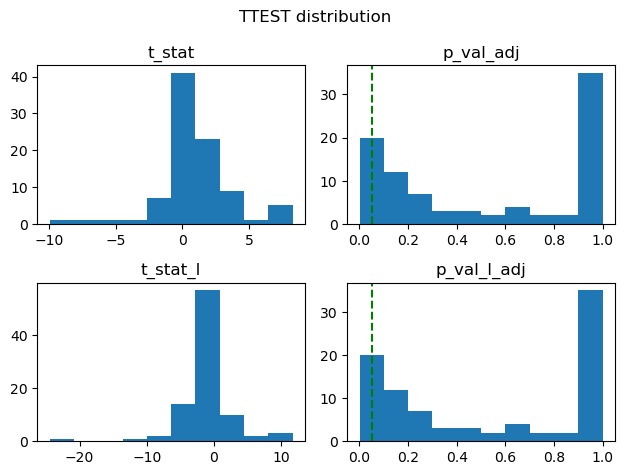

In [30]:
fig, axs = plot(2, 2, "TTEST distribution", df, [["t_stat", "p_val_adj"], ["t_stat_l", "p_val_l_adj"]])
axs[0, 1].axvline(0.05, linestyle="--", color="green")
axs[1, 1].axvline(0.05, linestyle="--", color="green")

### Fold change

In [14]:
## fold change between 22deg and 37deg
df["log2_fc"] = df["mean_37deg"] - df["mean_22deg"] # -> FC = 1 means under heat stress compound is twice as high 
df["log2_fc_l"] = df["mean_37deg_l"] - df["mean_22deg_l"]
df

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,mean_37deg_l,sd_37deg_l,t_stat,p_val,p_val_adj,t_stat_l,p_val_l,p_val_l_adj,log2_fc,log2_fc_l
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,-6.642695,0.189664,-1.855890,0.084641,0.217647,-6.689172,1.028446e-05,0.217647,0.149932,1.403277
2,Cer_d18:1_16:0,0.000041,0.000041,0.000041,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,-18.158106,1.101266,-2.352883,0.033777,0.121598,0.000000,1.000000e+00,0.121598,2.896638,0.000000
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,-5.691142,0.152419,-5.339919,0.000104,0.001043,-11.673109,1.332222e-08,0.001043,0.866858,1.994469
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,-7.561858,0.691253,8.102152,0.000001,0.000035,0.112026,9.123928e-01,0.000035,-1.024581,-0.030071
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,-7.378252,0.488697,0.999204,0.334654,0.621088,-1.301147,2.142155e-01,0.621088,-0.172103,0.260561
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC(t18:0/h26:1),0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,...,-18.158106,1.101266,0.000000,1.000000,1.000000,0.000000,1.000000e+00,1.000000,0.000000,0.000000
172,GIPC(t18:1/h26:0),5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,-15.655958,4.099805,0.505461,0.621099,0.961844,0.467826,6.471083e-01,0.961844,-0.062061,-0.962371
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,-16.287900,2.990075,0.084159,0.934122,1.000000,-0.538965,5.983779e-01,1.000000,-0.029158,0.724482
176,GIPC_t18:0_h28:1,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,...,-18.158106,1.101266,0.000000,1.000000,1.000000,0.000000,1.000000e+00,1.000000,0.000000,0.000000


## Skewness

In [15]:
df["skew_22deg_abs"] = [skew(df.filter(regex=r".*_22deg_\d+$").values[i]) for i in range(len(df))]
df["skew_37deg_abs"] = [skew(df.filter(regex=r".*_37deg_\d+$").values[i]) for i in range(len(df))]
df["skew_22deg_rel"] = [skew(df.filter(regex=r".*_22deg_\d+_rel$").values[i]) for i in range(len(df))]
df["skew_37deg_rel"] = [skew(df.filter(regex=r".*_37deg_\d+_rel$").values[i]) for i in range(len(df))]
df

C:\Users\janni\AppData\Local\Temp\ipykernel_25800\2819833365.py:1: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  df["skew_22deg_abs"] = [skew(df.filter(regex=r".*_22deg_\d+$").values[i]) for i in range(len(df))]
C:\Users\janni\AppData\Local\Temp\ipykernel_25800\2819833365.py:2: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  df["skew_37deg_abs"] = [skew(df.filter(regex=r".*_37deg_\d+$").values[i]) for i in range(len(df))]


,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,p_val_adj,t_stat_l,p_val_l,p_val_l_adj,log2_fc,log2_fc_l,skew_22deg_abs,skew_37deg_abs,skew_22deg_rel,skew_37deg_rel
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,0.217647,-6.689172,1.028446e-05,0.217647,0.149932,1.403277,0.054856,0.080237,-0.243084,0.135326
2,Cer_d18:1_16:0,0.000041,0.000041,0.000041,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,0.121598,0.000000,1.000000e+00,0.121598,2.896638,0.000000,1.661996,2.241589,-0.416579,1.801308
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,0.001043,-11.673109,1.332222e-08,0.001043,0.866858,1.994469,0.068238,0.142589,-0.185771,-0.155612
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,0.000035,0.112026,9.123928e-01,0.000035,-1.024581,-0.030071,0.144948,0.086108,0.123299,0.161683
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,0.621088,-1.301147,2.142155e-01,0.621088,-0.172103,0.260561,0.117633,0.120059,-0.267947,0.224132
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC(t18:0/h26:1),0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,...,1.000000,0.000000,1.000000e+00,1.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000
172,GIPC(t18:1/h26:0),5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,0.961844,0.467826,6.471083e-01,0.961844,-0.062061,-0.962371,0.026585,0.087619,-0.022294,0.321832
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,1.000000,-0.538965,5.983779e-01,1.000000,-0.029158,0.724482,0.059257,0.264747,-0.027168,0.118000
176,GIPC_t18:0_h28:1,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,...,1.000000,0.000000,1.000000e+00,1.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000


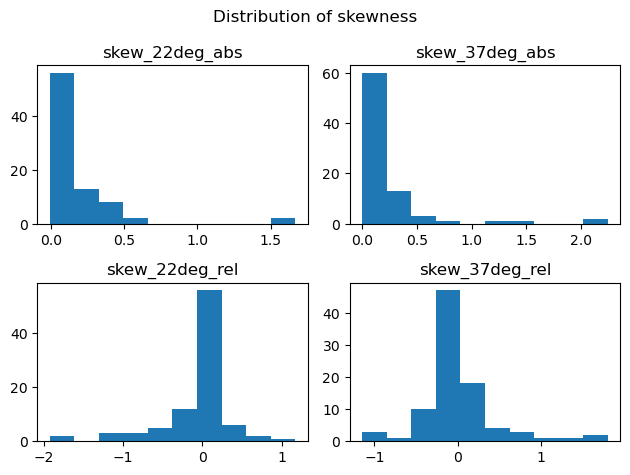

In [16]:
plot(2, 2, "Distribution of skewness", df, [["skew_22deg_abs", "skew_37deg_abs"], ["skew_22deg_rel", "skew_37deg_rel"]])

## Degree of labeling

In [17]:
df["sum_22deg"] = df[["mean_22deg", "mean_22deg_l"]].sum(axis=1)
df["sum_37deg"] = df[["mean_37deg", "mean_37deg_l"]].sum(axis=1)
df["dol_22deg"] = df["mean_22deg_l"] /  df["sum_22deg"]
df["dol_37deg"] = df["mean_37deg_l"] /  df["sum_37deg"]
df.to_csv("../data/formated/wt_24h.csv", index=False)
df

,compound,exp2_22deg_1,exp2_22deg_2,exp2_22deg_3,exp2_22deg_4,exp2_37deg_1,exp2_37deg_2,exp2_37deg_3,exp2_37deg_4,exp4_22deg_1,...,log2_fc,log2_fc_l,skew_22deg_abs,skew_37deg_abs,skew_22deg_rel,skew_37deg_rel,sum_22deg,sum_37deg,dol_22deg,dol_37deg
0,Cer_d18:0_16:1,0.506794,0.467428,0.386137,0.460704,0.754213,0.676763,0.549523,0.678189,4.935150,...,0.149932,1.403277,0.054856,0.080237,-0.243084,0.135326,-15.755435,-14.202225,0.510679,0.467722
2,Cer_d18:1_16:0,0.000041,0.000041,0.000041,0.033255,0.026626,0.040432,0.037791,0.019042,0.199781,...,2.896638,0.000000,1.661996,2.241589,-0.416579,1.801308,-31.345014,-28.448376,0.579298,0.638283
4,Cer_d18:0_16:0,1.210520,0.803832,0.621677,0.743999,3.185767,3.097204,2.965481,3.012839,8.686575,...,0.866858,1.994469,0.068238,0.142589,-0.185771,-0.155612,-14.817182,-11.955855,0.518696,0.476013
6,Cer_t18:1_16:0,1.732958,1.495523,1.395262,1.312457,0.382436,0.361044,0.380428,0.401221,13.188044,...,-1.024581,-0.030071,0.144948,0.086108,0.123299,0.161683,-14.189746,-15.244398,0.530791,0.496042
8,Cer_t18:0_16:0,0.997917,0.707813,0.576620,0.574825,0.559931,0.517615,0.555869,0.530521,10.628841,...,-0.172103,0.260561,0.117633,0.120059,-0.267947,0.224132,-14.777268,-14.688809,0.516930,0.502304
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,GIPC(t18:0/h26:1),0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,...,0.000000,0.000000,NaN,NaN,0.000000,0.000000,-36.316212,-36.316212,0.500000,0.500000
172,GIPC(t18:1/h26:0),5.383232,6.318330,6.079550,6.377095,6.067604,6.211469,5.814376,7.037880,81.874659,...,-0.062061,-0.962371,0.026585,0.087619,-0.022294,0.321832,-19.655064,-20.679496,0.747573,0.757076
174,GIPC_t18:1_h28:1,0.081139,0.110194,0.115272,0.102578,0.126090,0.112992,0.097118,0.121930,3.175120,...,-0.029158,0.724482,0.059257,0.264747,-0.027168,0.118000,-25.616201,-24.920876,0.664126,0.653585
176,GIPC_t18:0_h28:1,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,0.000041,...,0.000000,0.000000,NaN,NaN,0.000000,0.000000,-36.316212,-36.316212,0.500000,0.500000


Text(0.5, 0.98, 'Distribution of labeling degree')

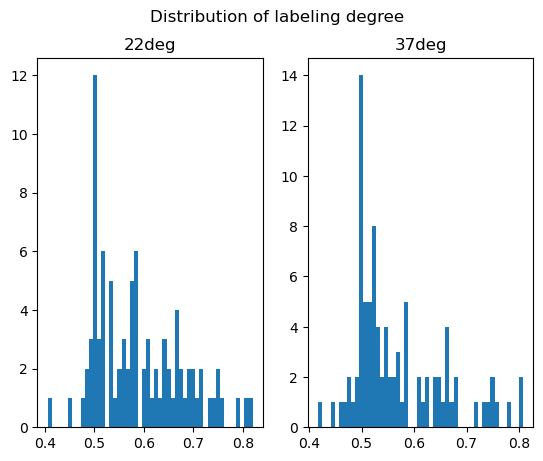

In [18]:
fig, axs = plt.subplots(1, 2)

for i, title in zip([0, 1], ["dol_22deg", "dol_37deg"]):
    axs[i].hist(df[title].values, bins=50)
    axs[i].set_title(f"{title.split("_")[1]}")

plt.suptitle("Distribution of labeling degree")

# To Do
- label degree
- volcano plot
- PCA

# Notes